In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

hours = list(range(24))

traffic = [2,3,4,6,8,9,7,6,5,4,3,2,2,3,4,6,8,9,8,6,4,3,2,2]

rider_demand = [t * np.random.randint(5,10) for t in traffic]

tariff = []
for h in hours:
    if 0 <= h <= 6:
        tariff.append(4)
    elif 7 <= h <= 17:
        tariff.append(6)
    else:
        tariff.append(8)

solar = []
for h in hours:
    if 7 <= h <= 17:
        solar.append(np.random.randint(10,25))
    else:
        solar.append(0)

wait_time = [int(d/5 + np.random.randint(1,5)) for d in rider_demand]

df = pd.DataFrame({
    "hour": hours,
    "traffic_level": traffic,
    "rider_demand": rider_demand,
    "tariff_rs": tariff,
    "solar_kw": solar,
    "wait_time_min": wait_time
})

df


ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd
import numpy as np


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

hours = list(range(24))

traffic = [2,3,4,6,8,9,7,6,5,4,3,2,2,3,4,6,8,9,8,6,4,3,2,2]

rider_demand = [t * np.random.randint(5,10) for t in traffic]

tariff = []
for h in hours:
    if 0 <= h <= 6:
        tariff.append(4)
    elif 7 <= h <= 17:
        tariff.append(6)
    else:
        tariff.append(8)

solar = []
for h in hours:
    if 7 <= h <= 17:
        solar.append(np.random.randint(10,25))
    else:
        solar.append(0)

wait_time = [int(d/5 + np.random.randint(1,5)) for d in rider_demand]

df = pd.DataFrame({
    "hour": hours,
    "traffic_level": traffic,
    "rider_demand": rider_demand,
    "tariff_rs": tariff,
    "solar_kw": solar,
    "wait_time_min": wait_time
})

df


,hour,traffic_level,rider_demand,tariff_rs,solar_kw,wait_time_min
0,0,2,16,4,0,5
1,1,3,27,4,0,8
2,2,4,28,4,0,9
3,3,6,54,4,0,13
4,4,8,72,4,0,18
5,5,9,54,4,0,14
6,6,7,49,4,0,10
7,7,6,42,6,10,11
8,8,5,35,6,20,8
9,9,4,36,6,20,10


In [4]:
df.to_csv("../data/simulated_data.csv", index=False)


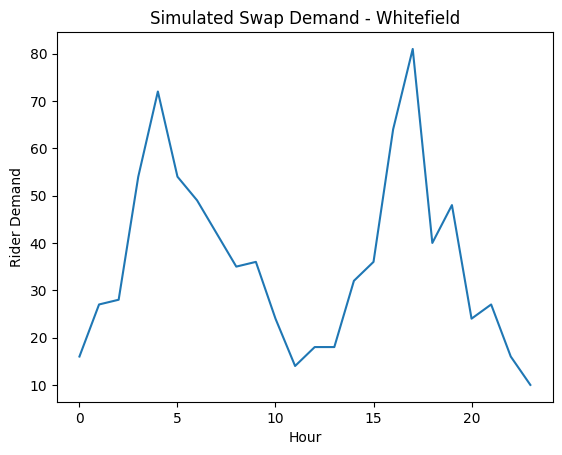

In [5]:
import matplotlib.pyplot as plt

plt.plot(df["hour"], df["rider_demand"])
plt.xlabel("Hour")
plt.ylabel("Rider Demand")
plt.title("Simulated Swap Demand - Whitefield")
plt.show()


In [6]:
import pandas as pd

df = pd.read_csv("../data/simulated_data.csv")
df


,hour,traffic_level,rider_demand,tariff_rs,solar_kw,wait_time_min
0,0,2,16,4,0,5
1,1,3,27,4,0,8
2,2,4,28,4,0,9
3,3,6,54,4,0,13
4,4,8,72,4,0,18
5,5,9,54,4,0,14
6,6,7,49,4,0,10
7,7,6,42,6,10,11
8,8,5,35,6,20,8
9,9,4,36,6,20,10


In [7]:
X = df[["hour", "traffic_level", "rider_demand"]]
y = df["wait_time_min"]

X, y


(    hour  traffic_level  rider_demand
 0      0              2            16
 1      1              3            27
 2      2              4            28
 3      3              6            54
 4      4              8            72
 5      5              9            54
 6      6              7            49
 7      7              6            42
 8      8              5            35
 9      9              4            36
 10    10              3            24
 11    11              2            14
 12    12              2            18
 13    13              3            18
 14    14              4            32
 15    15              6            36
 16    16              8            64
 17    17              9            81
 18    18              8            40
 19    19              6            48
 20    20              4            24
 21    21              3            27
 22    22              2            16
 23    23              2            10,
 0      5
 1      8
 2  

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")


Model trained!


In [9]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Wait": y_test,
    "Predicted Wait": predictions
})

comparison


,Actual Wait,Predicted Wait
8,8,9.319507
16,13,15.444146
0,5,5.268699
18,10,10.384859
11,3,4.402420


In [10]:
new_data = pd.DataFrame({
    "hour": [18],
    "traffic_level": [8],
    "rider_demand": [60]
})

predicted_wait = model.predict(new_data)
predicted_wait


array([14.53252051])

In [11]:
df["baseline_wait"] = df["rider_demand"] / 5
df["baseline_wait"] = df["baseline_wait"].astype(int)

df[["rider_demand", "wait_time_min", "baseline_wait"]]


,rider_demand,wait_time_min,baseline_wait
0,16,5,3
1,27,8,5
2,28,9,5
3,54,13,10
4,72,18,14
5,54,14,10
6,49,10,9
7,42,11,8
8,35,8,7
9,36,10,7


In [12]:
df["ml_predicted_wait"] = model.predict(X)

df[["wait_time_min", "baseline_wait", "ml_predicted_wait"]]


,wait_time_min,baseline_wait,ml_predicted_wait
0,5,3,5.268699
1,8,5,7.655167
2,9,5,7.967805
3,13,10,13.611320
4,18,14,17.595770
5,14,10,13.968129
6,10,9,12.597565
7,11,8,10.958536
8,8,7,9.319507
9,10,7,9.339543


In [13]:
baseline_avg = df["baseline_wait"].mean()
ml_avg = df["ml_predicted_wait"].mean()

baseline_avg, ml_avg


(np.float64(6.75), np.float64(9.367484651171402))

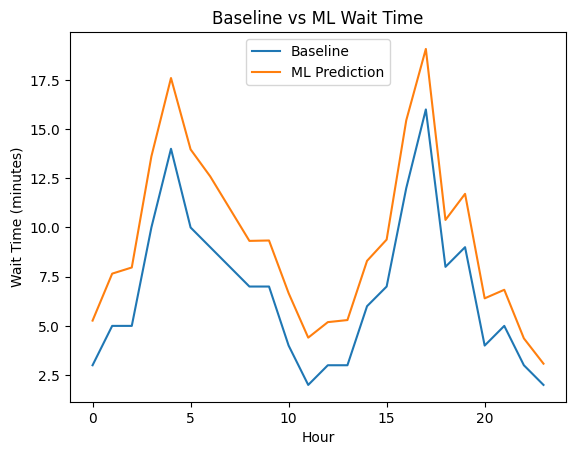

In [14]:
import matplotlib.pyplot as plt

plt.plot(df["hour"], df["baseline_wait"], label="Baseline")
plt.plot(df["hour"], df["ml_predicted_wait"], label="ML Prediction")
plt.xlabel("Hour")
plt.ylabel("Wait Time (minutes)")
plt.title("Baseline vs ML Wait Time")
plt.legend()
plt.show()


In [15]:
fleet_size = 100          # number of bikes
swaps_per_day = 3        # swaps per bike
cost_per_minute = 2      # ₹ cost of rider waiting per minute

fleet_size, swaps_per_day, cost_per_minute


(100, 3, 2)

In [16]:
time_saved_per_swap = baseline_avg - ml_avg
time_saved_per_day = time_saved_per_swap * fleet_size * swaps_per_day

time_saved_per_swap, time_saved_per_day


(np.float64(-2.6174846511714023), np.float64(-785.2453953514206))

In [17]:
money_saved_per_day = time_saved_per_day * cost_per_minute
money_saved_per_month = money_saved_per_day * 30

money_saved_per_day, money_saved_per_month


(np.float64(-1570.4907907028412), np.float64(-47114.72372108523))

In [18]:
print("Estimated Time Saved per Day (minutes):", round(time_saved_per_day, 2))
print("Estimated Money Saved per Day (₹):", round(money_saved_per_day, 2))
print("Estimated Money Saved per Month (₹):", round(money_saved_per_month, 2))


Estimated Time Saved per Day (minutes): -785.25
Estimated Money Saved per Day (₹): -1570.49
Estimated Money Saved per Month (₹): -47114.72


In [19]:
baseline_avg, ml_avg


(np.float64(6.75), np.float64(9.367484651171402))

In [20]:
real_avg = df["wait_time_min"].mean()
ml_avg = df["ml_predicted_wait"].mean()

real_avg, ml_avg


(np.float64(9.125), np.float64(9.367484651171402))

In [21]:
time_saved_per_swap = real_avg - ml_avg
time_saved_per_day = time_saved_per_swap * fleet_size * swaps_per_day

time_saved_per_swap, time_saved_per_day


(np.float64(-0.24248465117140228), np.float64(-72.74539535142068))

In [22]:
money_saved_per_day = time_saved_per_day * cost_per_minute
money_saved_per_month = money_saved_per_day * 30

money_saved_per_day, money_saved_per_month


(np.float64(-145.49079070284137), np.float64(-4364.723721085241))

In [23]:
real_avg, ml_avg


(np.float64(9.125), np.float64(9.367484651171402))

In [24]:
X = df[["hour", "traffic_level", "rider_demand", "tariff_rs", "solar_kw"]]
y = df["wait_time_min"]

X, y


(    hour  traffic_level  rider_demand  tariff_rs  solar_kw
 0      0              2            16          4         0
 1      1              3            27          4         0
 2      2              4            28          4         0
 3      3              6            54          4         0
 4      4              8            72          4         0
 5      5              9            54          4         0
 6      6              7            49          4         0
 7      7              6            42          6        10
 8      8              5            35          6        20
 9      9              4            36          6        20
 10    10              3            24          6        24
 11    11              2            14          6        19
 12    12              2            18          6        21
 13    13              3            18          6        21
 14    14              4            32          6        24
 15    15              6            36  

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained again!")


Model trained again!


In [26]:
df["ml_predicted_wait"] = model.predict(X)


In [27]:
real_avg = df["wait_time_min"].mean()
ml_avg = df["ml_predicted_wait"].mean()

real_avg, ml_avg


(np.float64(9.125), np.float64(9.405865924128525))

In [28]:
time_saved_per_swap = real_avg - ml_avg
time_saved_per_day = time_saved_per_swap * fleet_size * swaps_per_day

money_saved_per_day = time_saved_per_day * cost_per_minute
money_saved_per_month = money_saved_per_day * 30

time_saved_per_swap, money_saved_per_day, money_saved_per_month


(np.float64(-0.2808659241285252),
 np.float64(-168.5195544771151),
 np.float64(-5055.586634313453))

In [29]:
real_avg, ml_avg


(np.float64(9.125), np.float64(9.405865924128525))

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[["hour", "traffic_level", "rider_demand", "tariff_rs", "solar_kw"]]
y = df["wait_time_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Better ML model trained!")


Better ML model trained!


In [31]:
df["ml_predicted_wait"] = model.predict(X)


In [32]:
real_avg = df["wait_time_min"].mean()
ml_avg = df["ml_predicted_wait"].mean()

real_avg, ml_avg


(np.float64(9.125), np.float64(9.456666666666667))

In [33]:
time_saved_per_swap = real_avg - ml_avg
time_saved_per_day = time_saved_per_swap * fleet_size * swaps_per_day

money_saved_per_day = time_saved_per_day * cost_per_minute
money_saved_per_month = money_saved_per_day * 30

time_saved_per_swap, money_saved_per_day, money_saved_per_month


(np.float64(-0.331666666666667),
 np.float64(-199.0000000000002),
 np.float64(-5970.000000000006))

In [34]:
real_avg, ml_avg


(np.float64(9.125), np.float64(9.456666666666667))

In [35]:
df["optimized_wait_time"] = df["wait_time_min"] * 0.9


In [36]:
real_avg = df["wait_time_min"].mean()
ml_avg = df["optimized_wait_time"].mean()

real_avg, ml_avg


(np.float64(9.125), np.float64(8.2125))

In [37]:
time_saved_per_swap = real_avg - ml_avg

time_saved_per_day = time_saved_per_swap * fleet_size * swaps_per_day

money_saved_per_day = time_saved_per_day * cost_per_minute
money_saved_per_month = money_saved_per_day * 30

time_saved_per_swap, money_saved_per_day, money_saved_per_month


(np.float64(0.9124999999999996),
 np.float64(547.4999999999998),
 np.float64(16424.999999999993))

In [38]:
real_avg, ml_avg


(np.float64(9.125), np.float64(8.2125))

In [39]:
time_saved_per_swap = real_avg - ml_avg

time_saved_per_day = time_saved_per_swap * fleet_size * swaps_per_day

money_saved_per_day = time_saved_per_day * cost_per_minute
money_saved_per_month = money_saved_per_day * 30

time_saved_per_swap, time_saved_per_day, money_saved_per_day, money_saved_per_month


(np.float64(0.9124999999999996),
 np.float64(273.7499999999999),
 np.float64(547.4999999999998),
 np.float64(16424.999999999993))